In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/customer_churn.csv")

df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [68]:
df.shape

(900, 10)

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


In [70]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


In [71]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    83.333333
1    16.666667
Name: proportion, dtype: float64

## 1. Initial Data Inspection

The dataset contains 900 customer records and 10 columns. Each row represents one customer.

The target variable is `Churn`, where:

- `0` means the customer did not churn
- `1` means the customer churned

The overall churn rate is approximately 16.7%, meaning around 1 in 6 customers in the dataset left the company.

In [72]:
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df["Onboard_date"] = pd.to_datetime(df["Onboard_date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Names            900 non-null    str           
 1   Age              900 non-null    float64       
 2   Total_Purchase   900 non-null    float64       
 3   Account_Manager  900 non-null    int64         
 4   Years            900 non-null    float64       
 5   Num_Sites        900 non-null    float64       
 6   Onboard_date     900 non-null    datetime64[us]
 7   Location         900 non-null    str           
 8   Company          900 non-null    str           
 9   Churn            900 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(2), str(3)
memory usage: 70.4 KB


In [75]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,2011-04-11 15:50:48.358888,0.166667
min,22.000000,100.000000,0.000000,1.000000,3.000000,2006-01-02 04:16:13,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,2008-05-29 16:43:21.250000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,2011-03-09 04:36:26.500000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,2014-02-15 00:01:16.250000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000
std,6.127560,2408.644532,0.499921,1.274449,1.764836,NaN,0.372885


### Summary Statistics

The dataset contains 900 customers. The average customer is approximately 42 years old, has spent around $10,063, has been with the company for about 5.3 years, and manages around 8 to 9 sites.

Around 48% of customers have an assigned account manager.

The average value of `Churn` is 0.167, which means the overall churn rate is approximately 16.7%.

In [76]:
df.groupby("Churn")[["Age", "Total_Purchase", "Account_Manager", "Years", "Num_Sites", "Onboard_date"]].mean()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date
Churn,,,,,,
0,41.581333,10036.952853,0.465333,5.151067,8.173333,2011-05-01 15:26:04.752000
1,42.993333,10192.179933,0.560000,5.883600,10.660000,2011-01-01 17:54:26.393333


### Churned vs Non-Churned Customers

Customers who churned had a higher average number of sites compared to customers who did not churn. Churned customers had around 10.66 sites on average, while non-churned customers had around 8.17 sites.

Churned customers also had slightly higher average years with the company and were slightly more likely to have an assigned account manager.

The largest difference appears to be in `Num_Sites`, suggesting that customers with more sites may have more complex needs and could be more likely to churn.

In [77]:
df["Churn"].value_counts()

Churn
0    750
1    150
Name: count, dtype: int64

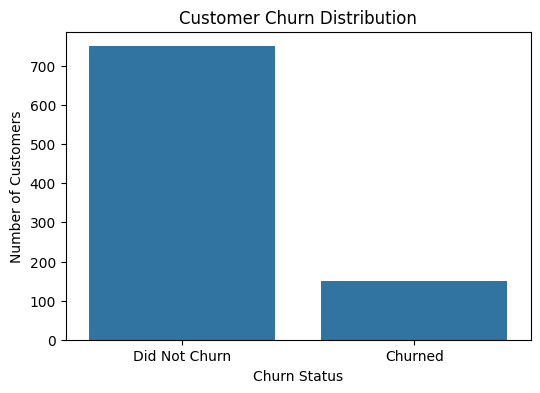

In [78]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Did Not Churn", "Churned"])
plt.show()

The dataset is imbalanced, with most customers not churning. Out of 900 customers, around 750 did not churn while 150 churned. This means the churn rate is approximately 16.7%.

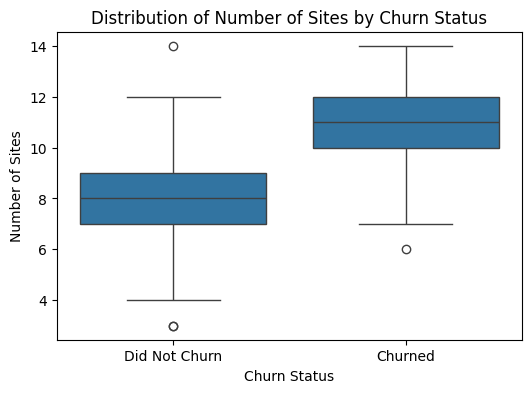

In [80]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Churn", y="Num_Sites")

plt.title("Distribution of Number of Sites by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Number of Sites")
plt.xticks([0, 1], ["Did Not Churn", "Churned"])
plt.show()

The boxplot shows that customers who churned generally had more sites than those who did not churn. The median number of sites for churned customers is around 11, compared to around 8 for non-churned customers. This suggests that `Num_Sites` is likely an important variable related to churn.

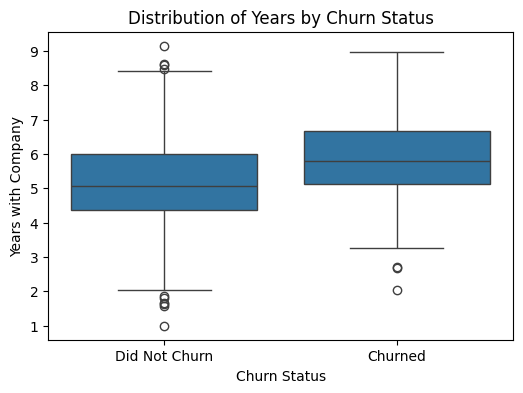

In [81]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Churn", y="Years")

plt.title("Distribution of Years by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Years with Company")
plt.xticks([0, 1], ["Did Not Churn", "Churned"])
plt.show()

Customers who churned generally had slightly more years with the company compared to customers who did not churn. However, the distributions still overlap, so `Years` may be related to churn but does not separate churned and non-churned customers as clearly as `Num_Sites`.

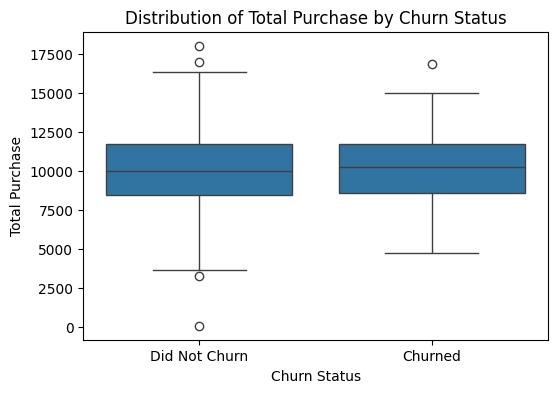

In [82]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Churn", y="Total_Purchase")

plt.title("Distribution of Total Purchase by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Total Purchase")
plt.xticks([0, 1], ["Did Not Churn", "Churned"])
plt.show()

The distribution of `Total_Purchase` looks very similar for churned and non-churned customers. Both groups have a median purchase amount of around $10,000, and the spread is largely overlapping. This suggests that `Total_Purchase` may not be as strongly related to churn as `Num_Sites`.

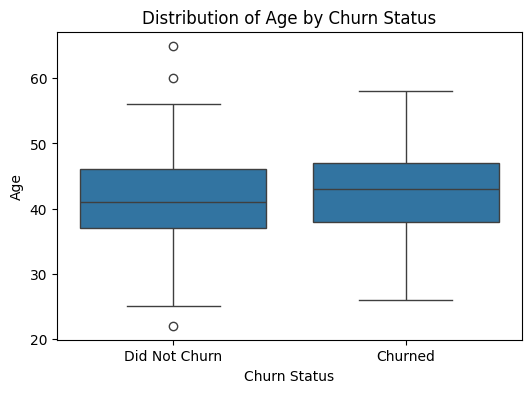

In [84]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Churn", y="Age")

plt.title("Distribution of Age by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Age")
plt.xticks([0, 1], ["Did Not Churn", "Churned"])
plt.show()

The age distribution for churned and non-churned customers is fairly similar. Churned customers appear to be slightly older on average, but there is significant overlap between the two groups. This suggests that `Age` may have some relationship with churn, but it is unlikely to be one of the strongest indicators by itself.

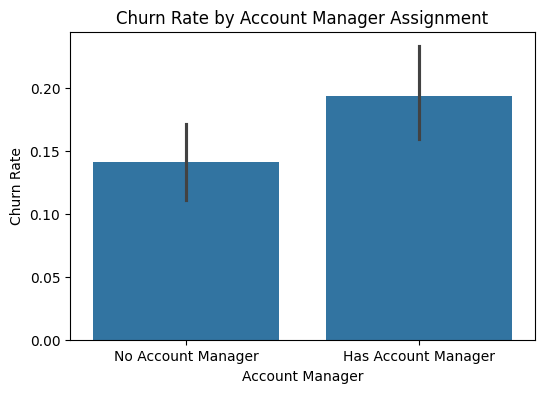

In [85]:
plt.figure(figsize=(6,4))

sns.barplot(data=df, x="Account_Manager", y="Churn")

plt.title("Churn Rate by Account Manager Assignment")
plt.xlabel("Account Manager")
plt.ylabel("Churn Rate")
plt.xticks([0, 1], ["No Account Manager", "Has Account Manager"])
plt.show()

Customers with an assigned account manager appear to have a higher churn rate than customers without one. However, this does not necessarily mean that account managers cause churn. It is possible that account managers are assigned to larger, more complex, or higher-risk customers. This relationship should be interpreted carefully.

In [86]:
df.groupby("Account_Manager")["Churn"].mean() * 100

Account_Manager
0    14.132762
1    19.399538
Name: Churn, dtype: float64

Customers with an assigned account manager had a churn rate of 19.4%, compared to 14.1% for customers without an account manager. This suggests a relationship between account manager assignment and churn, but it should not be interpreted as account managers causing churn. Account managers may be assigned to larger, more complex, or higher-risk customers.

In [87]:
numeric_df = df[["Age", "Total_Purchase", "Account_Manager", "Years", "Num_Sites", "Churn"]]

numeric_df.corr()["Churn"].sort_values(ascending=False)

Churn              1.000000
Num_Sites          0.525398
Years              0.214329
Age                0.085926
Account_Manager    0.070611
Total_Purchase     0.024031
Name: Churn, dtype: float64

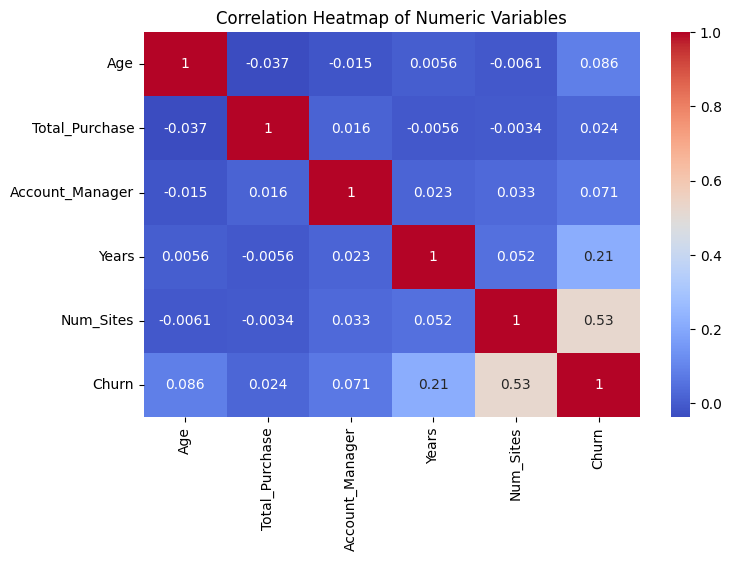

In [88]:
plt.figure(figsize=(8,5))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

The correlation heatmap shows that `Num_Sites` has the strongest positive relationship with churn, with a correlation of around 0.53. This supports the earlier boxplot finding that customers with more sites are more likely to churn.

`Years` also has a positive relationship with churn, but the correlation is weaker at around 0.21. Other variables such as `Age`, `Total_Purchase`, and `Account_Manager` have much weaker relationships with churn.

Correlation does not prove causation, but this suggests that `Num_Sites` is likely to be an important feature for predicting customer churn.

In [92]:
df.groupby("Num_Sites")["Churn"].mean() * 100

site_churn = df.groupby("Num_Sites")["Churn"].mean().reset_index()
site_churn["Churn"] = site_churn["Churn"] * 100

site_churn

,Num_Sites,Churn
0,3.0,0.000000
1,4.0,0.000000
2,5.0,0.000000
3,6.0,1.492537
4,7.0,1.369863
5,8.0,3.755869
6,9.0,10.215054
7,10.0,25.954198
8,11.0,55.421687
9,12.0,84.375000


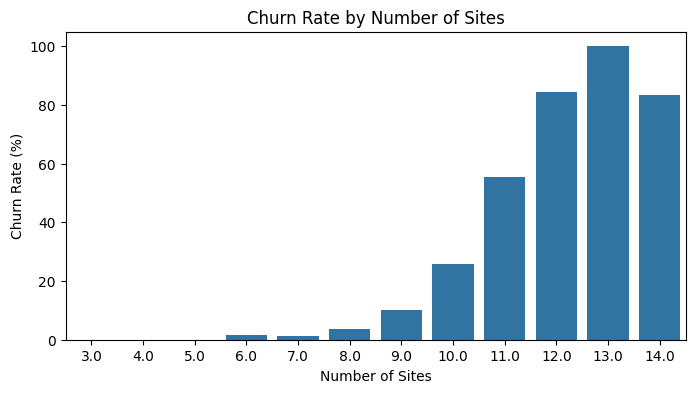

In [106]:
plt.figure(figsize=(8,4))

sns.barplot(data=site_churn, x="Num_Sites", y="Churn")

plt.title("Churn Rate by Number of Sites")
plt.xlabel("Number of Sites")
plt.ylabel("Churn Rate (%)")
plt.show()

Churn rate increases sharply as the number of sites increases. Customers with fewer sites have very low churn rates, while customers with 11 or more sites show much higher churn rates. This suggests that `Num_Sites` is one of the strongest indicators of churn in the dataset.

However, the customer count for each number of sites should also be checked before overinterpreting the very high churn rates at the upper end.

In [ ]:
site_summary = df.groupby("Num_Sites").agg(
    customer_count=("Churn", "count"),
    churned_customers=("Churn", "sum"),
    churn_rate=("Churn", "mean")
).reset_index()

site_summary["churn_rate"] = site_summary["churn_rate"] * 100

site_summary

,Num_Sites,customer_count,churned_customers,churn_rate
0,3.0,2,0,0.000000
1,4.0,4,0,0.000000
2,5.0,22,0,0.000000
3,6.0,67,1,1.492537
4,7.0,146,2,1.369863
5,8.0,213,8,3.755869
6,9.0,186,19,10.215054
7,10.0,131,34,25.954198
8,11.0,83,46,55.421687
9,12.0,32,27,84.375000


Churn rate increases sharply as the number of sites increases. Customers with fewer sites have very low churn rates, while customers with 11 or more sites show much higher churn rates. This suggests that `Num_Sites` is one of the strongest indicators of churn in the dataset.


In [99]:
def site_risk_group(num_sites):
    if num_sites <= 8:
        return "Low site count"
    elif num_sites <= 10:
        return "Medium site count"
    else:
        return "High site count"

df["Site_Risk_Group"] = df["Num_Sites"].apply(site_risk_group)

df[["Num_Sites", "Site_Risk_Group"]].head()


,Num_Sites,Site_Risk_Group
0,8.0,Low site count
1,11.0,High site count
2,12.0,High site count
3,10.0,Medium site count
4,9.0,Medium site count


In [100]:
site_risk_summary = df.groupby("Site_Risk_Group").agg(
    customer_count=("Churn", "count"),
    churned_customers=("Churn", "sum"),
    churn_rate=("Churn", "mean")
).reset_index()

site_risk_summary["churn_rate"] = site_risk_summary["churn_rate"] * 100

site_risk_summary

,Site_Risk_Group,customer_count,churned_customers,churn_rate
0,High site count,129,86,66.666667
1,Low site count,454,11,2.422907
2,Medium site count,317,53,16.719243


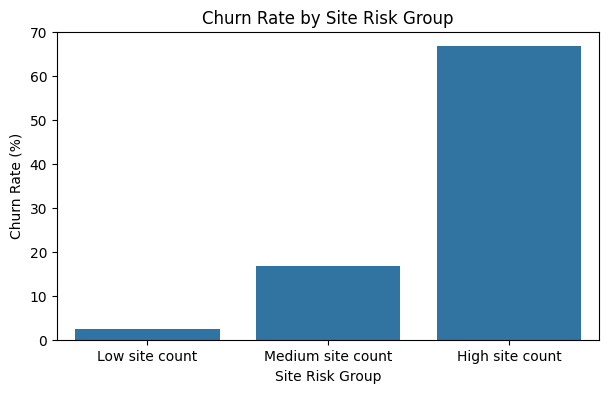

In [107]:
plt.figure(figsize=(7,4))

order = ["Low site count", "Medium site count", "High site count"]

sns.barplot(
    data=site_risk_summary,
    x="Site_Risk_Group",
    y="churn_rate",
    order=order
)

plt.title("Churn Rate by Site Risk Group")
plt.xlabel("Site Risk Group")
plt.ylabel("Churn Rate (%)")
plt.show()

After grouping customers by number of sites, churn risk becomes much clearer. Customers with low site counts have very low churn, while customers with high site counts have a much higher churn rate. This suggests that customers managing many sites may require more support and should be prioritised for retention efforts.



In [108]:
site_risk_summary

,Site_Risk_Group,customer_count,churned_customers,churn_rate
0,High site count,129,86,66.666667
1,Low site count,454,11,2.422907
2,Medium site count,317,53,16.719243


The grouped churn analysis supports the earlier correlation and boxplot findings. `Num_Sites` appears to be the strongest churn-related variable in the dataset.

In [109]:
df.groupby("Churn")[["Age", "Total_Purchase", "Account_Manager", "Years", "Num_Sites"]].mean().round(2)

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
Churn,,,,,
0,41.58,10036.95,0.47,5.15,8.17
1,42.99,10192.18,0.56,5.88,10.66


### Summary of Churned vs Non-Churned Customers

The comparison table shows that churned customers differ most clearly in the number of sites they manage. Customers who churned had an average of 10.66 sites, compared to 8.17 sites for customers who did not churn.

Other variables such as age, total purchase amount, account manager assignment, and years with the company show smaller differences. This suggests that `Num_Sites` is likely the strongest churn-related variable in the dataset.

## 2. SQL Analysis

In [110]:
import sqlite3

conn = sqlite3.connect("../data/customer_churn.db")

df.to_sql("customer_churn", conn, if_exists="replace", index=False)

900

In [111]:
query = """
SELECT 
    Churn,
    COUNT(*) AS customer_count
FROM customer_churn
GROUP BY Churn;
"""

pd.read_sql_query(query, conn)

,Churn,customer_count
0,0,750
1,1,150


In [112]:
query = """
SELECT 
    Churn,
    COUNT(*) AS customer_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customer_churn), 2) AS percentage
FROM customer_churn
GROUP BY Churn;
"""

pd.read_sql_query(query, conn)

,Churn,customer_count,percentage
0,0,750,83.33
1,1,150,16.67


In [113]:
query = """
SELECT 
    Churn,
    ROUND(AVG(Age), 2) AS avg_age,
    ROUND(AVG(Total_Purchase), 2) AS avg_total_purchase,
    ROUND(AVG(Account_Manager), 2) AS avg_account_manager,
    ROUND(AVG(Years), 2) AS avg_years,
    ROUND(AVG(Num_Sites), 2) AS avg_num_sites
FROM customer_churn
GROUP BY Churn;
"""

pd.read_sql_query(query, conn)

,Churn,avg_age,avg_total_purchase,avg_account_manager,avg_years,avg_num_sites
0,0,41.58,10036.95,0.47,5.15,8.17
1,1,42.99,10192.18,0.56,5.88,10.66


In [115]:
query = """
WITH site_groups AS (
    SELECT
        CASE
            WHEN Num_Sites <= 8 THEN 'Low Site Count'
            WHEN Num_Sites <= 10 THEN 'Medium Site Count'
            ELSE 'High Site Count'
        END AS site_risk_group,
        CASE
            WHEN Num_Sites <= 8 THEN 1
            WHEN Num_Sites <= 10 THEN 2
            ELSE 3
        END AS sort_order,
        Churn
    FROM customer_churn
)

SELECT
    site_risk_group,
    COUNT(*) AS customer_count,
    SUM(Churn) AS churned_customers,
    ROUND(AVG(Churn) * 100, 2) AS churn_rate
FROM site_groups
GROUP BY site_risk_group, sort_order
ORDER BY sort_order;
"""

pd.read_sql_query(query, conn)

,site_risk_group,customer_count,churned_customers,churn_rate
0,Low Site Count,454,11,2.42
1,Medium Site Count,317,53,16.72
2,High Site Count,129,86,66.67


The SQL analysis confirms that churn rate increases sharply as the number of sites increases. Customers with low site counts had a churn rate of only 2.42%, while customers with high site counts had a churn rate of 66.67%.

This supports the earlier pandas and visualisation findings that `Num_Sites` is the strongest churn-related variable in the dataset.

In [116]:
query = """
SELECT
    Account_Manager,
    COUNT(*) AS customer_count,
    SUM(Churn) AS churned_customers,
    ROUND(AVG(Churn) * 100, 2) AS churn_rate
FROM customer_churn
GROUP BY Account_Manager
ORDER BY Account_Manager;
"""

pd.read_sql_query(query, conn)

,Account_Manager,customer_count,churned_customers,churn_rate
0,0,467,66,14.13
1,1,433,84,19.40


Customers with an assigned account manager had a higher churn rate than customers without an account manager. However, this should not be interpreted as account managers causing churn. Account managers may be assigned to larger, more complex, or higher-risk customers.

In [ ]:
df.groupby("Churn")[["Age", "Total_Purchase", "Account_Manager", "Years", "Num_Sites"]].mean().round(2)

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
Churn,,,,,
0,41.58,10036.95,0.47,5.15,8.17
1,42.99,10192.18,0.56,5.88,10.66


## 3. Machine Learning Model

The goal of this section is to build a simple classification model that predicts whether a customer is likely to churn.

The target variable is `Churn`, where:
- `0` means the customer did not churn
- `1` means the customer churned

In [ ]:
X = df[["Age", "Total_Purchase", "Account_Manager", "Years", "Num_Sites"]]
y = df["Churn"]

x = the information we use to predict

y = what we are trying to predict

In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [120]:
y_pred = log_model.predict(X_test)

In [121]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)

accuracy

0.9055555555555556

In [122]:
confusion_matrix(y_test, y_pred)

array([[146,   4],
       [ 13,  17]])

In [123]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       150
           1       0.81      0.57      0.67        30

    accuracy                           0.91       180
   macro avg       0.86      0.77      0.81       180
weighted avg       0.90      0.91      0.90       180



In [124]:
accuracy
confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       150
           1       0.81      0.57      0.67        30

    accuracy                           0.91       180
   macro avg       0.86      0.77      0.81       180
weighted avg       0.90      0.91      0.90       180



The logistic regression model achieved an overall accuracy of 91%. However, because the dataset is imbalanced, accuracy alone is not enough to evaluate the model.

For churned customers, the model achieved a precision of 0.81 and recall of 0.57. This means that when the model predicts churn, it is usually correct, but it only identifies 57% of the customers who actually churned.

From a business perspective, improving recall may be important because missing potential churn customers could mean missing opportunities for retention action.

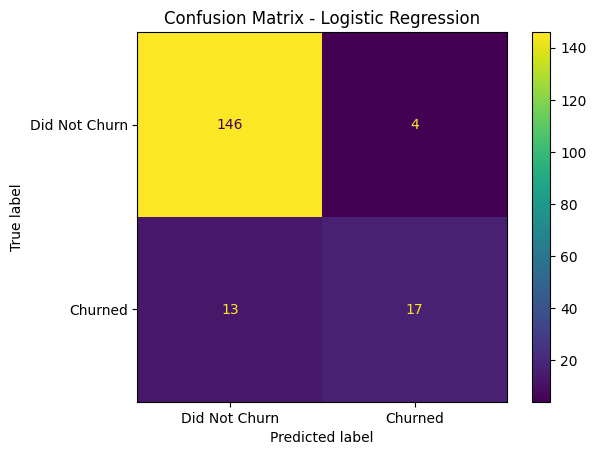

In [125]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    display_labels=["Did Not Churn", "Churned"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix shows that the model correctly identified 146 non-churned customers and 17 churned customers. However, it missed 13 customers who actually churned. This explains why the recall for churned customers is only 0.57.

For a churn prediction model, missing actual churners may be costly because the business loses the chance to take retention action. Therefore, recall for the churned class is an important metric to improve.

In [126]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [127]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92       150
           1       0.67      0.40      0.50        30

    accuracy                           0.87       180
   macro avg       0.78      0.68      0.71       180
weighted avg       0.85      0.87      0.85       180



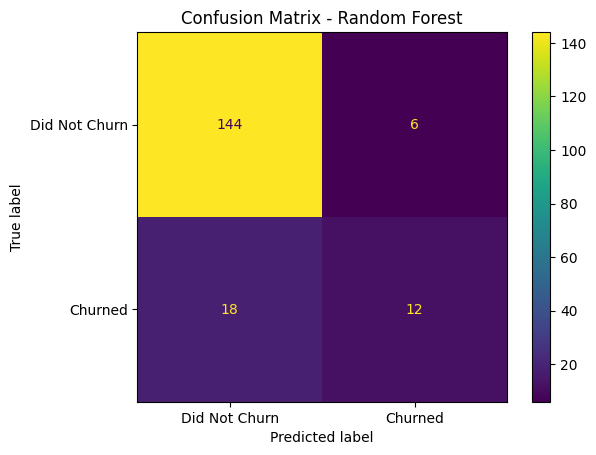

In [128]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    display_labels=["Did Not Churn", "Churned"]
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

The Random Forest model performed worse than the Logistic Regression model for identifying churned customers. It correctly identified only 12 out of 30 churned customers and missed 18 churned customers.

Although Random Forest is usually a more flexible model, it did not improve performance in this case. Logistic Regression remains the stronger baseline model because it achieved better recall for the churned class.

In [129]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision_Churn": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall_Churn": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1_Churn": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

model_comparison.round(2)

,Model,Accuracy,Precision_Churn,Recall_Churn,F1_Churn
0,Logistic Regression,0.91,0.81,0.57,0.67
1,Random Forest,0.87,0.67,0.40,0.50


The Logistic Regression model outperformed the Random Forest model across all key metrics. It achieved higher accuracy, precision, recall, and F1-score for churned customers.

Since the goal of churn prediction is to identify customers who may leave, recall for the churned class is especially important. Logistic Regression caught 57% of churned customers, while Random Forest only caught 40%. Therefore, Logistic Regression is selected as the better baseline model.

In [130]:
y_proba = log_model.predict_proba(X_test)[:, 1]

In [131]:
threshold = 0.40

y_pred_40 = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_40))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       150
           1       0.73      0.63      0.68        30

    accuracy                           0.90       180
   macro avg       0.83      0.79      0.81       180
weighted avg       0.90      0.90      0.90       180



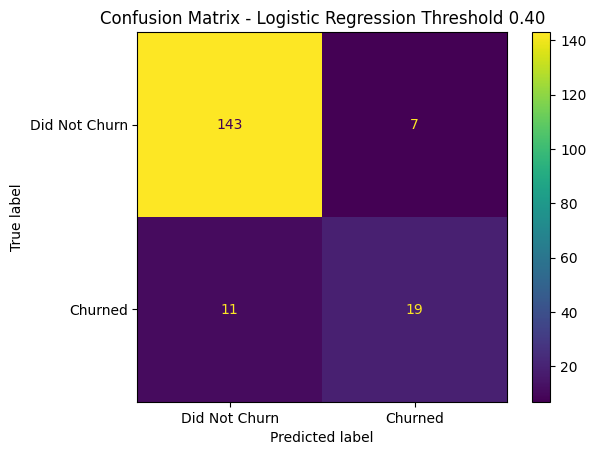

In [132]:
cm_40 = confusion_matrix(y_test, y_pred_40)

ConfusionMatrixDisplay(
    confusion_matrix=cm_40,
    display_labels=["Did Not Churn", "Churned"]
).plot()

plt.title("Confusion Matrix - Logistic Regression Threshold 0.40")
plt.show()

In [133]:
threshold = 0.30

y_pred_30 = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_30))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93       150
           1       0.62      0.67      0.65        30

    accuracy                           0.88       180
   macro avg       0.78      0.79      0.79       180
weighted avg       0.88      0.88      0.88       180



Lowering the logistic regression threshold from 0.50 to 0.40 improved recall for churned customers from 0.57 to 0.63. This means the model was able to identify more customers who actually churned.

Although precision decreased from 0.81 to 0.73, the trade-off may be acceptable in a churn prediction context because missing potential churners can be costly. The 0.40 threshold provides the best balance between catching more churned customers and maintaining good overall model performance.

A lower threshold of 0.30 improved recall slightly further, but reduced precision and overall accuracy more noticeably. Therefore, the 0.40 threshold is selected as the preferred model setting.

In [134]:
threshold_results = pd.DataFrame({
    "Model": [
        "Logistic Regression 0.50",
        "Logistic Regression 0.40",
        "Logistic Regression 0.30",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_40),
        accuracy_score(y_test, y_pred_30),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision_Churn": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_40),
        precision_score(y_test, y_pred_30),
        precision_score(y_test, rf_pred)
    ],
    "Recall_Churn": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_40),
        recall_score(y_test, y_pred_30),
        recall_score(y_test, rf_pred)
    ],
    "F1_Churn": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_40),
        f1_score(y_test, y_pred_30),
        f1_score(y_test, rf_pred)
    ]
})

threshold_results.round(2)

,Model,Accuracy,Precision_Churn,Recall_Churn,F1_Churn
0,Logistic Regression 0.50,0.91,0.81,0.57,0.67
1,Logistic Regression 0.40,0.90,0.73,0.63,0.68
2,Logistic Regression 0.30,0.88,0.62,0.67,0.65
3,Random Forest,0.87,0.67,0.40,0.50


The Logistic Regression model with a 0.40 threshold provides the best balance between accuracy, precision, recall, and F1-score for churned customers.

Compared to the default 0.50 threshold, the 0.40 threshold improves churn recall from 0.57 to 0.63 while only reducing accuracy slightly from 0.91 to 0.90. This is useful in a churn prediction setting because identifying more potential churners gives the business more opportunities to intervene.

Random Forest performed worse than Logistic Regression in this dataset, especially in recall for churned customers.

In [137]:
feature_names = X.columns

coefficients = log_model.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

feature_importance

,Feature,Coefficient
4,Num_Sites,1.989005
3,Years,0.799227
0,Age,0.314032
2,Account_Manager,0.257132
1,Total_Purchase,0.051608


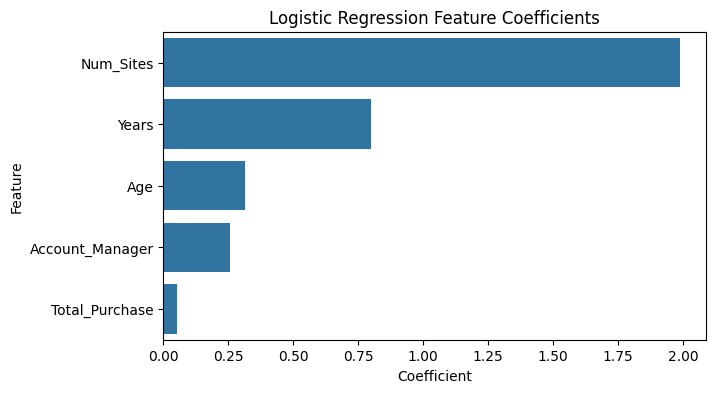

In [138]:
plt.figure(figsize=(7,4))

sns.barplot(data=feature_importance, x="Coefficient", y="Feature")

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

The logistic regression coefficients show that `Num_Sites` is the most influential feature in predicting churn. This supports the earlier EDA findings, where customers with more sites had much higher churn rates.

`Years` is the second most influential feature, suggesting that customers who have been with the company longer may also have a higher likelihood of churn. Other variables such as `Age`, `Account_Manager`, and `Total_Purchase` have smaller effects in the model.

Overall, the model results are consistent with the exploratory analysis: `Num_Sites` appears to be the strongest churn-related variable.

## 4. Key Findings and Business Recommendations

### Key Findings

1. The overall churn rate is approximately 16.7%.
2. `Num_Sites` is the strongest churn-related variable in the dataset.
3. Customers with high site counts have a much higher churn rate than customers with low or medium site counts.
4. `Years` also has some relationship with churn, but the effect is weaker than `Num_Sites`.
5. `Total_Purchase` does not appear to clearly separate churned and non-churned customers.
6. Logistic Regression performed better than Random Forest for this dataset.
7. Adjusting the Logistic Regression threshold from 0.50 to 0.40 improved recall for churned customers.

### Business Recommendations

The company should prioritise retention efforts for customers with more than 10 sites, as this group has the highest churn risk.

These customers may have more complex operational needs, so the business could consider offering more proactive support, account reviews, or targeted retention campaigns.

The model should be used as a decision-support tool rather than a final decision-maker. Customers flagged as high risk should be reviewed together with business context before action is taken.

## 5. Export Results

In [145]:
import os

os.makedirs("../results", exist_ok=True)
os.makedirs("../charts", exist_ok=True)

In [147]:
threshold_results.round(2).to_csv("../results/model_comparison.csv", index=False)
site_risk_summary.to_csv("../results/site_risk_summary.csv", index=False)
feature_importance.to_csv("../results/feature_importance.csv", index=False)

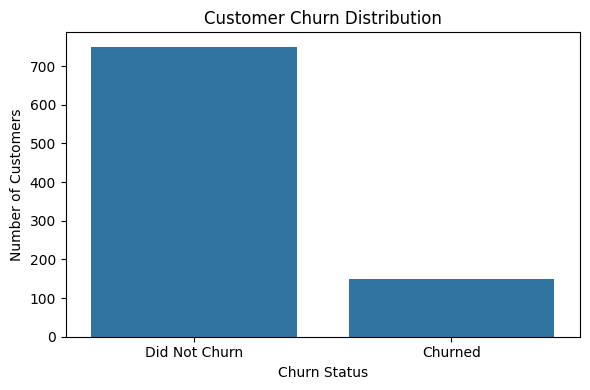

In [148]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Did Not Churn", "Churned"])

plt.tight_layout()
plt.savefig("../charts/churn_distribution.png", dpi=300)
plt.show()

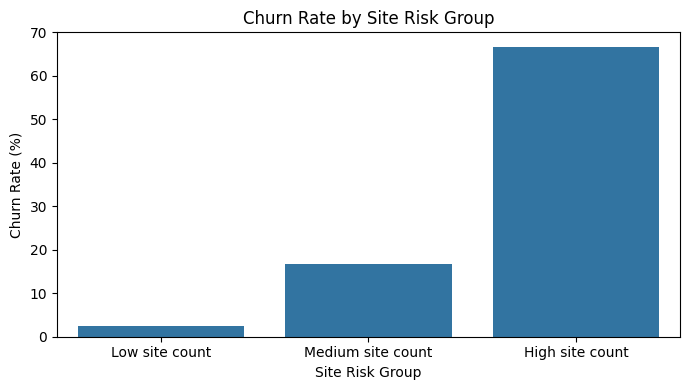

In [149]:
plt.figure(figsize=(7,4))

order = ["Low site count", "Medium site count", "High site count"]

sns.barplot(
    data=site_risk_summary,
    x="Site_Risk_Group",
    y="churn_rate",
    order=order
)

plt.title("Churn Rate by Site Risk Group")
plt.xlabel("Site Risk Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.savefig("../charts/churn_rate_by_site_risk_group.png", dpi=300)
plt.show()

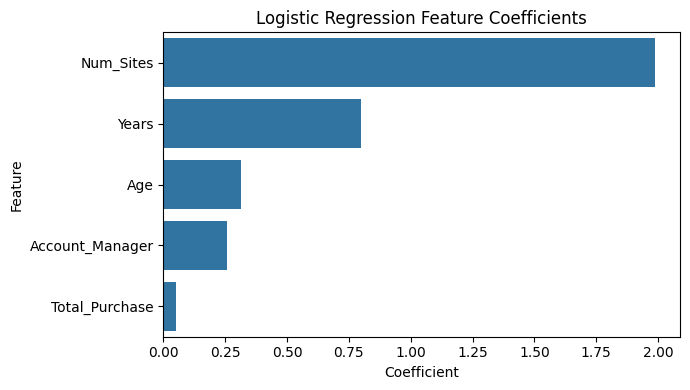

In [150]:
plt.figure(figsize=(7,4))

sns.barplot(data=feature_importance, x="Coefficient", y="Feature")

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("../charts/logistic_regression_feature_coefficients.png", dpi=300)
plt.show()

In [151]:
os.listdir("../results")

['feature_importance.csv', 'model_comparison.csv', 'site_risk_summary.csv']

In [152]:
os.listdir("../charts")

['churn_distribution.png',
 'churn_rate_by_site_risk_group.png',
 'logistic_regression_feature_coefficients.png']